## Setup

In [1]:
# Set project root to ChessClassification

import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.append(project_root)

print(f"Project root added to path: {project_root}")

Project root added to path: /home/zmoraj/ChessClassification


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from torchvision import transforms, models
from src.network.training import train
from src.network.evaluation import evaluate, evaluate_with_solver
from src.preprocessing.dataset import ChessBoardDataset
from src.utils.dataset_utils import calculate_stats, build_transforms
from src.utils.plotting import plot_training_history

In [3]:
# Load data 

TRAIN_DATA_ROOT = os.path.join(project_root, "data/train/real")
VAL_DATA_ROOT = os.path.join(project_root, "data/validation/real")
TEST_REAL_DATA_ROOT = os.path.join(project_root, "data/test/real")
BATCH_SIZE = 2
NUM_WORKERS = 4
SIZE = 112

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

# Compute statistics
train_mean, train_std, test_mean, test_std = calculate_stats(TRAIN_DATA_ROOT, TEST_REAL_DATA_ROOT, SIZE, SIZE, NUM_WORKERS)

# Build final datasets and DataLoaders
baseline_config = {} 
train_transform = build_transforms(train_mean, train_std, config=baseline_config)
test_transform = build_transforms(test_mean, test_std, config=baseline_config)

train_dataset = ChessBoardDataset(root_dir=TRAIN_DATA_ROOT, transform=train_transform, padding=1.0)
val_dataset = ChessBoardDataset(root_dir=VAL_DATA_ROOT, transform=train_transform, padding=1.0)
test_real_dataset = ChessBoardDataset(root_dir=TEST_REAL_DATA_ROOT, transform=test_transform, padding=1.0)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_real_loader = DataLoader(test_real_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

device: cuda
Training samples: 238 | Test samples: 204
Computing mean and std for training data...


Calculating Stats: 100%|██████████| 15/15 [00:04<00:00,  3.20it/s]



Calculated training mean: [0.6852758526802063, 0.6504018902778625, 0.5687229037284851]
Calculated training std:  [0.13094593584537506, 0.13619399070739746, 0.12317227572202682]

Computing mean and std for test data...


Calculating Stats: 100%|██████████| 13/13 [00:04<00:00,  3.25it/s]


Calculated test mean: [0.7058276534080505, 0.6708773374557495, 0.585018515586853]
Calculated test std:  [0.1342628300189972, 0.1405027061700821, 0.128083735704422]



In [4]:
def setup_model(backbone_path):
    
    model = torch.load(backbone_path, weights_only=False)
    
    for param in model.parameters():
        param.requires_grad = False

    # Final Linear layer
    for param in model.classifier[2].parameters():
        param.requires_grad = True
    
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters (Classification Head only): {trainable_params:,}")
    
    return model

In [17]:
# Initialize model

model = setup_model(os.path.join(project_root, 'models/convnext_new_data.pth')).to(device)

Trainable parameters (Classification Head only): 9,997


## Training

Training on cuda for 15 epochs...


Training Progress:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 1/15 | Train: Loss=0.2120 Acc=0.9429  Val: Loss=0.0944 Acc=0.9736   [Saved Best]
Epoch 2/15 | Train: Loss=0.0780 Acc=0.9842  Val: Loss=0.0772 Acc=0.9792   [Saved Best]
Epoch 3/15 | Train: Loss=0.0538 Acc=0.9900  Val: Loss=0.0708 Acc=0.9816   [Saved Best]
Epoch 4/15 | Train: Loss=0.0417 Acc=0.9928  Val: Loss=0.0672 Acc=0.9839   [Saved Best]
Epoch 5/15 | Train: Loss=0.0354 Acc=0.9940  Val: Loss=0.0681 Acc=0.9832  
Epoch 6/15 | Train: Loss=0.0317 Acc=0.9949  Val: Loss=0.0681 Acc=0.9825  
Epoch 7/15 | Train: Loss=0.0284 Acc=0.9949  Val: Loss=0.0661 Acc=0.9844   [Saved Best]
Epoch 8/15 | Train: Loss=0.0261 Acc=0.9959  Val: Loss=0.0652 Acc=0.9837  
Epoch 9/15 | Train: Loss=0.0254 Acc=0.9959  Val: Loss=0.0630 Acc=0.9853   [Saved Best]
Epoch 10/15 | Train: Loss=0.0235 Acc=0.9963  Val: Loss=0.0635 Acc=0.9855   [Saved Best]
Epoch 11/15 | Train: Loss=0.0224 Acc=0.9965  Val: Loss=0.0627 Acc=0.9858   [Saved Best]
Epoch 12/15 | Train: Loss=0.0211 Acc=0.9968  Val: Loss=0.0643 Acc=0.9851  
Epoch

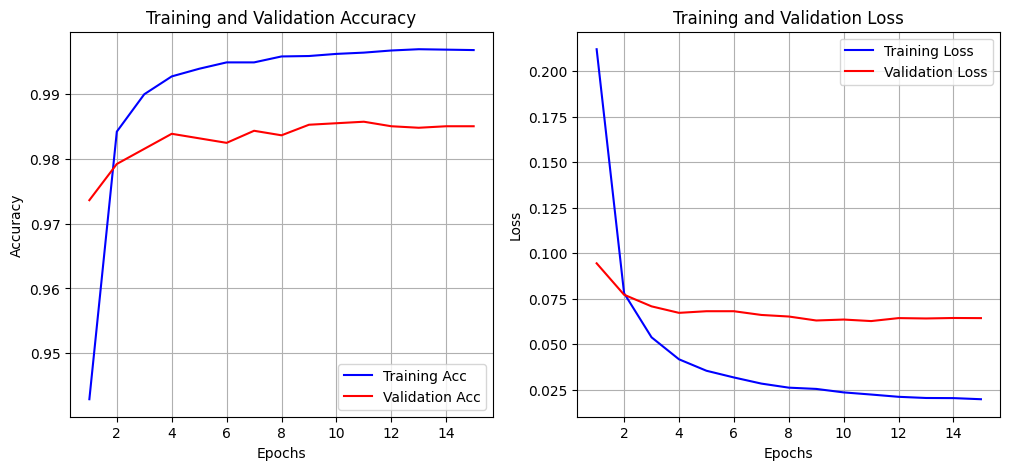

In [18]:
# Training loop

# Configuration
lr = 1e-3
num_epochs = 15
criterion = nn.CrossEntropyLoss()
params = filter(lambda p: p.requires_grad, model.parameters())
optimizer = optim.Adam(params, lr=lr)
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

# Training
best_model, history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=num_epochs,
    device=device,
    save_path=os.path.join(project_root, 'models/convnext_fine_tuned_head.pth')
)

# Plotting train and validation statistics
plot_training_history(history)

## Evaluation

In [19]:
# Evaluation on real test data

test_real_dataset.return_fen = False
square_acc, board_acc = evaluate(best_model, test_real_loader, device)

print(f"Square accuracy: {square_acc:.2f}")
print(f"Board accuracy: {board_acc:.2f}")

Starting Evaluation on 204 boards...


Evaluating: 100%|██████████| 102/102 [00:12<00:00,  8.29it/s]

Square accuracy: 94.69
Board accuracy: 2.94


In [20]:
# Evaluation with solver on real test data

test_real_dataset.return_fen = False
square_acc, board_acc = evaluate_with_solver(best_model, test_real_loader, device)

print(f"Square accuracy: {square_acc:.2f}")
print(f"Board accuracy: {board_acc:.2f}")

Starting solver evaluation on 204 boards...


Solver Inference: 100%|██████████| 102/102 [00:20<00:00,  4.90it/s]

Square accuracy: 96.65
Board accuracy: 16.67
